In [205]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [206]:
df=pd.read_csv("customer_segmentation.csv")

In [207]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [208]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [209]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [210]:
df['Age'] = 2026-pd.to_numeric(df['Year_Birth'])

In [211]:
df.shape

(2240, 30)

In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [213]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
dtype: int64

In [214]:
df.isnull().sum().sum()

np.int64(24)

In [215]:
df.dropna(inplace=True)

In [216]:
df.isnull().sum().sum()

np.int64(0)

In [217]:
df.shape

(2216, 30)

In [218]:
df.value_counts()

ID     Year_Birth  Education   Marital_Status  Income   Kidhome  Teenhome  Dt_Customer  Recency  MntWines  MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  NumDealsPurchases  NumWebPurchases  NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  Z_CostContact  Z_Revenue  Response  Age
11191  1986        Graduation  Divorced        41411.0  0        0         07-12-2013   11       37        32         38               11               3                 18            1                  2                1                    4                  6                  0             0             0             0             0             0         3              11         0         40     1
0      1985        Graduation  Married         70951.0  0        0         04-05-2013   66       239       10         554              254              87                54            1            

In [219]:
print("matrial_ststus")
df['Marital_Status'].value_counts()

matrial_ststus


Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [220]:
df['Teenhome'].value_counts()

Teenhome
0    1147
1    1018
2      51
Name: count, dtype: int64

In [221]:

df['Education'].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [222]:
df['Kidhome'].value_counts()

Kidhome
0    1283
1     887
2      46
Name: count, dtype: int64

In [223]:
df['Marital_Status']

0         Single
1         Single
2       Together
3       Together
4        Married
          ...   
2235     Married
2236    Together
2237    Divorced
2238    Together
2239     Married
Name: Marital_Status, Length: 2216, dtype: object

In [224]:
df['Education'].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

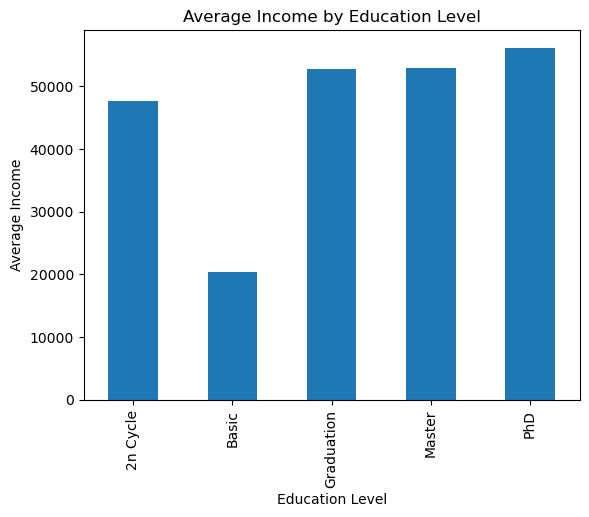

In [225]:
import matplotlib.pyplot as plt

income_by_edu = df.groupby('Education')['Income'].mean()

income_by_edu.plot(kind='bar')

plt.xlabel("Education Level")
plt.ylabel("Average Income")
plt.title("Average Income by Education Level")
plt.show()

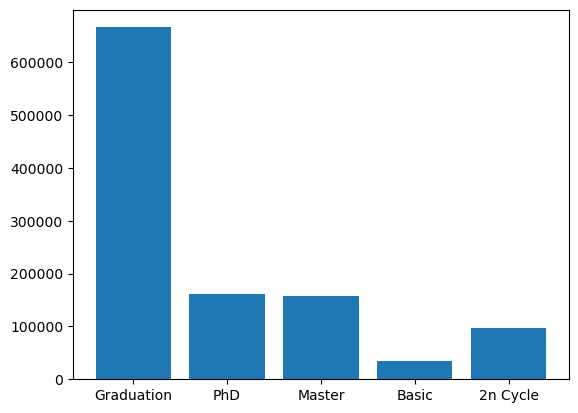

In [226]:
x=df['Education']
y=df['Income']
plt.bar(x,y)
plt.show()

In [227]:
start={'Graduation':2,'Master':3,'2n Cycle':1,'Basic':0,'PhD':4}
df['Education']=df['Education'].map(start)

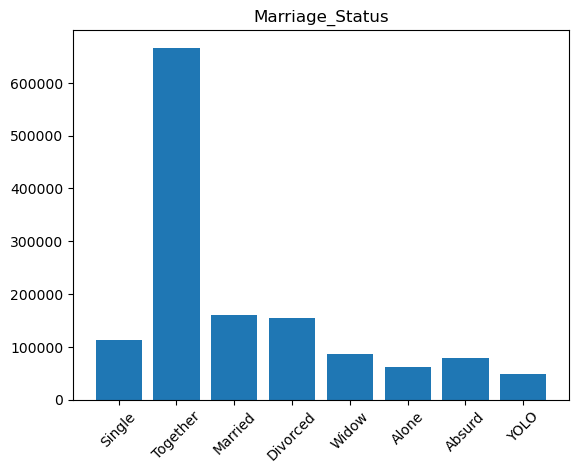

In [228]:
x=df['Marital_Status']
y=df['Income']
plt.bar(x,y)
plt.xticks(rotation=45)
plt.title('Marriage_Status')
plt.show()

In [229]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['Marital_Status']=encoder.fit_transform(df['Marital_Status'])

In [230]:
df['Total_kids']=df['Kidhome']+df['Teenhome']

In [231]:
df['Total_kids']

0       0
1       2
2       0
3       1
4       1
       ..
2235    1
2236    3
2237    0
2238    1
2239    2
Name: Total_kids, Length: 2216, dtype: int64

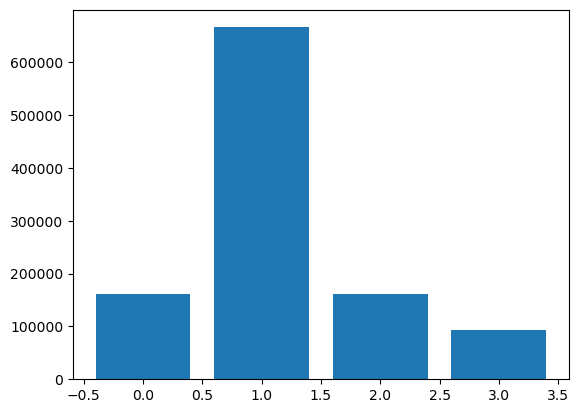

In [232]:
x=df['Total_kids']
y=df['Income']
plt.bar(x,y)
plt.show()

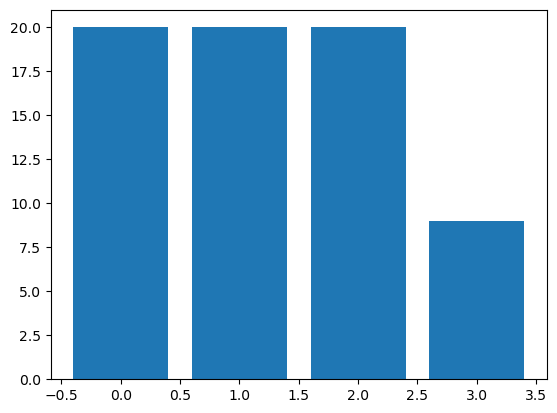

In [233]:
x=df['Total_kids']
y=df['NumWebVisitsMonth']
plt.bar(x,y)
plt.show()

In [234]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_kids'],
      dtype='object')

In [235]:
features=["Age","Income",'NumWebPurchases','NumStorePurchases','NumWebVisitsMonth']

In [236]:
x=df[features].copy()

In [237]:
x

,Age,Income,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth
0,69,58138.0,8,4,7
1,72,46344.0,1,2,5
2,61,71613.0,8,10,4
3,42,26646.0,2,4,6
4,45,58293.0,5,6,5
...,...,...,...,...,...
2235,59,61223.0,9,4,5
2236,80,64014.0,8,5,7
2237,45,56981.0,2,13,6
2238,70,69245.0,6,10,3


In [238]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [239]:
x_scaled=scaler.fit_transform(x)

In [240]:
x_scaled

array([[ 0.98644293,  0.2340627 ,  1.42855332, -0.55414289,  0.69323197],
       [ 1.23680074, -0.23455948, -1.12588116, -1.16951781, -0.1315745 ],
       [ 0.31882209,  0.76947764,  1.42855332,  1.29198186, -0.54397773],
       ...,
       [-1.01641959,  0.18809052, -0.76096195,  2.21504423,  0.28082874],
       [ 1.06989553,  0.67538765,  0.6987149 ,  1.29198186, -0.95638097],
       [ 1.23680074,  0.02470453, -0.39604274, -0.55414289,  0.69323197]])

In [241]:
list1=[]
for i in range(2,10):
  Kmeans=KMeans(n_clusters=i)
  Kmeans.fit(x_scaled)
  list1.append(Kmeans.inertia_)

c:\Users\YASWANTH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\YASWANTH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\YASWANTH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\YASWANTH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory le

In [242]:
list1

[7192.1108241489965,
 5994.395886087873,
 5304.103744011851,
 4738.581482675649,
 4437.157789017234,
 4172.700568270088,
 3660.2938217978485,
 3425.077508473298]

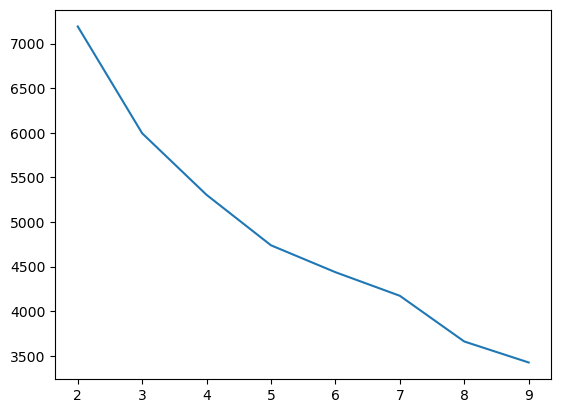

In [243]:
plt.plot(range(2,10),list1)
plt.show()

In [244]:
Kmeans=KMeans(n_clusters=5)
df['Clusters']=Kmeans.fit_predict(x_scaled)

c:\Users\YASWANTH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


In [245]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_kids,Clusters
0,5524,1957,2,4,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,3,11,1,69,0,1
1,2174,1954,2,4,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,3,11,0,72,2,2
2,4141,1965,2,5,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,3,11,0,61,0,1
3,6182,1984,2,5,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,3,11,0,42,1,4
4,5324,1981,4,3,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,3,11,0,45,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,2,3,61223.0,0,1,13-06-2013,46,709,...,0,0,0,0,3,11,0,59,1,1
2236,4001,1946,4,5,64014.0,2,1,10-06-2014,56,406,...,0,1,0,0,3,11,0,80,3,1
2237,7270,1981,2,2,56981.0,0,0,25-01-2014,91,908,...,0,0,0,0,3,11,0,45,0,0
2238,8235,1956,3,5,69245.0,0,1,24-01-2014,8,428,...,0,0,0,0,3,11,0,70,1,3


In [246]:
import joblib

In [247]:
import joblib

# Path to your .dist folder
save_path = r"C:\Users\YASWANTH\OneDrive\Desktop\k classifier(usml)\.dist"

# Save the KMeans model
joblib.dump(Kmeans, f"{save_path}\\kmeans_model.pkl")

# Save the scaler
joblib.dump(scaler, f"{save_path}\\scaler.pkl")

['C:\\Users\\YASWANTH\\OneDrive\\Desktop\\k classifier(usml)\\.dist\\scaler.pkl']